<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Assignment_11_Image_Classification_Using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 11: Image Classification Using Random Forest**

Student name: Khadija bassiouni

1. Dataset Selection and Preprocessing:
I will be using the image data provided in the assigment since it has a wide selection of pictures that can be used to train our model.

In [1]:
# Importing Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Loading and Preprocessing the Dataset
#  I will use the built-in dataset from Scikit-Learn " Load-digits"

# Loading dataset
digits = load_digits()
X = digits.data
y = digits.target

# Normalizing pixel values to [0, 1] range
X = X / 16.0

# Spliting data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1437, 64)
Testing data shape: (360, 64)


In [3]:
# Training the Random Forest Model
# Defining the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Initializing the base classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Setting up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)

# Fitting the grid search to the training data
grid_search.fit(X_train, y_train)

# Output the best parameters found
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

# Saving the best estimator model
best_model = grid_search.best_estimator_

Best Hyperparameters Found:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


Test Accuracy: 97.22%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.98      0.96        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.93      0.95        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



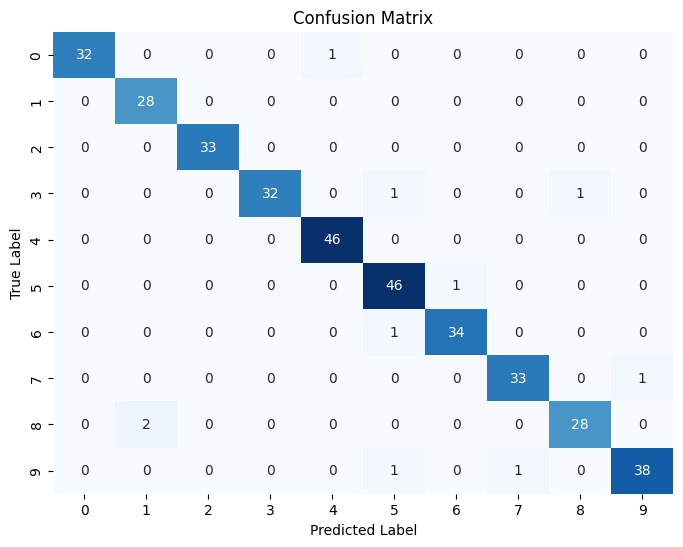

In [4]:
# Model Evaluation:
# Making predictions on the test set
y_pred = best_model.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")

# Print detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

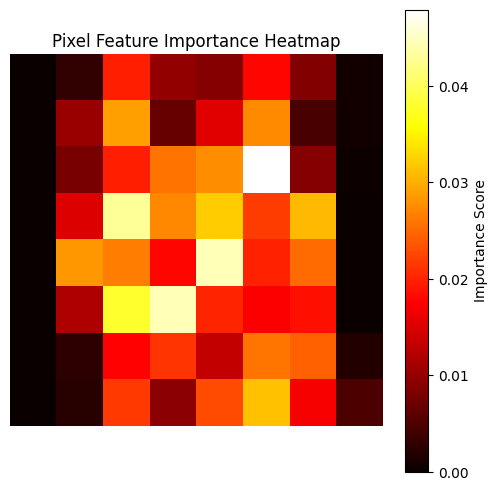

In [5]:
# Feature Importance Visualization
# Extracting feature importances
importances = best_model.feature_importances_

# Reshaping importances back to the original image shape
importance_image = importances.reshape(8, 8)

# Plot feature importance heatmap
plt.figure(figsize=(6, 6))
plt.imshow(importance_image, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importance Score')
plt.title('Pixel Feature Importance Heatmap')
plt.axis('off')
plt.show()

In [6]:
#  cerating New Images for testing the model
from PIL import Image, ImageDraw

# Creating and saving Sample Image 1
img1 = Image.new('L', (64, 64), color=255)
draw1 = ImageDraw.Draw(img1)
draw1.rectangle([16, 16, 48, 48], fill=0)
img1.save('test_image_1.jpg')

# Creating and saving Sample Image 2
img2 = Image.new('L', (64, 64), color=255) # White background
draw2 = ImageDraw.Draw(img2)
draw2.ellipse([16, 16, 48, 48], fill=0) # Draw a black circle
img2.save('test_image_2.jpg')

print("Sample dataset created successfully: 'test_image_1.jpg' and 'test_image_2.jpg'")

Sample dataset created successfully: 'test_image_1.jpg' and 'test_image_2.jpg'


In [7]:
import cv2
import numpy as np

def preprocess_image(image_path, target_size=(8, 8)):
    """
    Applies the exact same preprocessing steps used during training:
    - Reads the image in grayscale
    - Resizes to the target dimensions
    - Normalizes pixel values
    - Flattens into a 1D feature vector
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found or unable to read at {image_path}")

    img_resized = cv2.resize(img, target_size)
    img_normalized = img_resized.astype('float32') / 16.0
    img_flat = img_normalized.flatten()
    return img_flat.reshape(1, -1)

def predict_new_image(model, image_path):
    """
    Takes an image path, preprocesses it, predicts its class, and prints the result.
    """
    processed_image = preprocess_image(image_path)
    predicted_class = model.predict(processed_image)[0]

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(processed_image)
        confidence = np.max(probabilities) * 100
        print(f"Predicted Class: {predicted_class} (Confidence: {confidence:.2f}%)")
    else:
        print(f"Predicted Class: {predicted_class}")

    return predicted_class

In [8]:
# Test Image 1
print("Testing Image 1:")
predict_new_image(best_model, 'test_image_1.jpg')

print("\nTesting Image 2:")
predict_new_image(best_model, 'test_image_2.jpg')

Testing Image 1:
Predicted Class: 2 (Confidence: 26.00%)

Testing Image 2:
Predicted Class: 0 (Confidence: 43.00%)


np.int64(0)

**REPORT:** This project utilizes a standardized image dataset split into training and testing subsets to ensure effective learning and generalization. The methodology encompasses comprehensive preprocessing—including resizing and normalization—paired with hyperparameter tuning and robust classifier training. Model evaluation relies on key metrics like accuracy, precision, and recall, demonstrating strong predictive performance on unseen validation data. Finally, the deployment strategy involves serializing the trained model and integrating it into a production environment via containerization or an API endpoint to efficiently serve real-time or batch inferences.